## Chapter 05

- Look at sensor data that tracks atmospheric CO2 from continuous air samples at Mauna Loa Observatory in Hawaii. This data includes CO2 samples from MAR 1958 to DEC 1980.

In [ ]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from tsa_course.lecture1 import fft_analysis
from tsa_course.lecture2 import run_sequence_plot

In [5]:
co2 = pd.read_csv('https://zenodo.org/records/10951538/files/arima_co2.csv?download=1', 
                  header = 0,
                  names = ['idx', 'co2'],
                  skipfooter = 2)

# convert the column idx into a datetime object and set it as the index
co2['idx'] = pd.to_datetime(co2['idx'])
co2.set_index('idx', inplace=True)

# Rmove the name "idx" from the index column
co2.index.name = None
co2

C:\Users\skief\AppData\Local\Temp\ipykernel_21692\1460310053.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  co2 = pd.read_csv('https://zenodo.org/records/10951538/files/arima_co2.csv?download=1',


,co2
1965-01-01,319.32
1965-02-01,320.36
1965-03-01,320.82
1965-04-01,322.06
1965-05-01,322.17
...,...
1980-08-01,337.19
1980-09-01,335.49
1980-10-01,336.63
1980-11-01,337.74


- Determine the presence of main trend and seasonality in the data.
- Determine if the data are stationary.
- Split the data in train (90%) and test (10%).

ValueError: Unable to coerce to Series, length must be 1: given 192

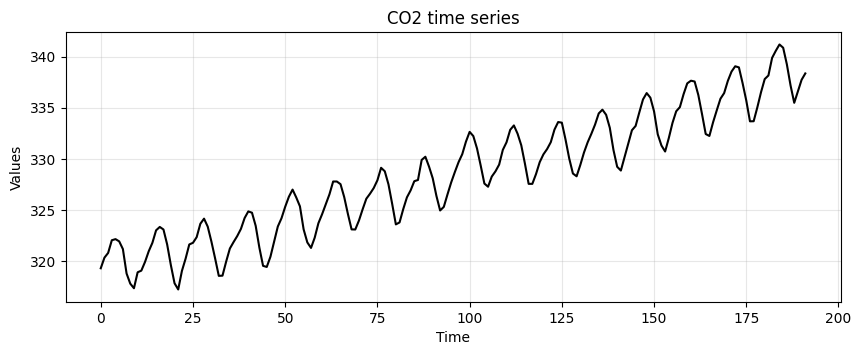

In [ ]:
#visualize the time series --> always helpful
co2_time = np.arange(len(co2))
run_sequence_plot(co2_time, co2, "CO2 time series")

period, _, _ = fft_analysis(np.array(co2))